# Bilbiotecas

In [3]:
import pandas               as pd
import numpy                as np
import matplotlib.pyplot    as plt
import seaborn              as sns
import math

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import RobustScaler
from sklearn.linear_model       import LogisticRegression
from sklearn.metrics            import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
    )

# Dataset

In [4]:
dataset = pd.read_csv('dados_brutos\\tarefas_clientes_logistic_regression.csv', sep=';')
# Convertendo colunas object com vírgula para float numérico
colunas_para_ajustar = [
    'valor_ativo_total', 'valor_cancelado_total', 
    'media_dias_exec', 'perc_prioridade_maxima', 'perc_tarefas_abertas'
]

for col in colunas_para_ajustar:
    dataset[col] = dataset[col].astype(str).str.replace(',', '.').astype(float)

dataset.head()

,cod_cliente,primeira_assinatura,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,...,qt_tarefas_bug,qt_tarefas_reducao,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,churn
0,10,2013-05-04,0.00,248.45,0,1,0,1,0,0,...,0,0,1,0,0,0,0,0.00,0.00,1
1,20,2001-03-20,3369.25,0.00,1,0,0,561,15,14,...,41,1,536,4,14,7,0,1.25,1.43,0
2,22,2011-03-21,0.00,545.60,0,2,0,64,265,0,...,0,0,62,0,0,2,0,3.13,0.00,1
3,29,2020-10-30,1056.93,0.00,1,0,0,14,126,0,...,0,0,12,1,0,1,0,7.14,0.00,0
4,32,2012-02-13,0.00,8153.38,0,1,0,62,392,0,...,0,0,60,1,1,0,0,0.00,0.00,1


In [5]:
dataset.isnull().sum().sum()

0

In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4668 entries, 0 to 4667
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   cod_cliente                  4668 non-null   int64  
 1   primeira_assinatura          4668 non-null   object 
 2   valor_ativo_total            4668 non-null   float64
 3   valor_cancelado_total        4668 non-null   float64
 4   qtd_contratos_ativos         4668 non-null   int64  
 5   qtd_contratos_cancelados     4668 non-null   int64  
 6   flg_ja_sofreu_downgrade      4668 non-null   int64  
 7   qtd_tarefas_total            4668 non-null   int64  
 8   dias_ultima_tarefa           4668 non-null   int64  
 9   tarefas_90d                  4668 non-null   int64  
 10  media_dias_exec              4668 non-null   float64
 11  qtd_tarefas_abertas          4668 non-null   int64  
 12  qtd_categorias_distintas     4668 non-null   int64  
 13  qtd_subcategorias_

In [7]:
media_dias_ano_bissexto = 30.44

# Por que não usar apenas 30?
# Se você dividir o total de dias por 30 em uma base histórica longa
# (como um cliente que está com você desde 2011, igual ao exemplo do cliente 17029),
# o modelo vai acumular um erro de quase 5 dias por ano. No longo prazo, isso faria o
# cálculo do Tenure (tempo de casa) parecer maior do que a realidade, adicionando meses "fantasmas" ao seu dataset.

In [8]:
# Transformando a 'primeira_assinatura' em Feature Numérica (Tenure em meses)
dataset['primeira_assinatura'] = pd.to_datetime(dataset['primeira_assinatura'])
data_referencia = dataset['primeira_assinatura'].max() # Ou use pd.Timestamp.now() se os dados forem em tempo real
dataset['meses_de_casa'] = ((data_referencia - dataset['primeira_assinatura']).dt.days / media_dias_ano_bissexto).astype(int)

In [9]:
dataset.head()

,cod_cliente,primeira_assinatura,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,...,qt_tarefas_reducao,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,churn,meses_de_casa
0,10,2013-05-04,0.00,248.45,0,1,0,1,0,0,...,0,1,0,0,0,0,0.00,0.00,1,156
1,20,2001-03-20,3369.25,0.00,1,0,0,561,15,14,...,1,536,4,14,7,0,1.25,1.43,0,301
2,22,2011-03-21,0.00,545.60,0,2,0,64,265,0,...,0,62,0,0,2,0,3.13,0.00,1,181
3,29,2020-10-30,1056.93,0.00,1,0,0,14,126,0,...,0,12,1,0,1,0,7.14,0.00,0,66
4,32,2012-02-13,0.00,8153.38,0,1,0,62,392,0,...,0,60,1,1,0,0,0.00,0.00,1,171


# Features

In [10]:
X = dataset.drop(['cod_cliente', 'primeira_assinatura', 'churn'], axis=1)
X

,valor_ativo_total,valor_cancelado_total,qtd_contratos_ativos,qtd_contratos_cancelados,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,media_dias_exec,qtd_tarefas_abertas,...,qt_tarefas_bug,qt_tarefas_reducao,qtd_prioridade_normal,qtd_prioridade_parcial,qtd_prioridade_urgente,qtd_prioridade_maxima,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,meses_de_casa
0,0.00,248.45,0,1,0,1,0,0,208.0000,0,...,0,0,1,0,0,0,0,0.00,0.00,156
1,3369.25,0.00,1,0,0,561,15,14,23.1960,8,...,41,1,536,4,14,7,0,1.25,1.43,301
2,0.00,545.60,0,2,0,64,265,0,12.2500,0,...,0,0,62,0,0,2,0,3.13,0.00,181
3,1056.93,0.00,1,0,0,14,126,0,30.1429,0,...,0,0,12,1,0,1,0,7.14,0.00,66
4,0.00,8153.38,0,1,0,62,392,0,67.2581,0,...,0,0,60,1,1,0,0,0.00,0.00,171
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4663,429.00,0.00,1,0,0,1,6,1,0.0000,1,...,0,0,1,0,0,0,0,0.00,100.00,0
4664,445.58,0.00,1,0,0,1,5,1,0.0000,1,...,0,0,1,0,0,0,0,0.00,100.00,9
4665,399.00,0.00,1,0,0,1,2,1,0.0000,1,...,0,0,1,0,0,0,0,0.00,100.00,0
4666,8998.00,0.00,1,0,0,0,43,0,0.0000,0,...,0,0,0,0,0,0,0,0.00,0.00,1


In [11]:
y = dataset['churn']
y

0       1
1       0
2       1
3       0
4       1
       ..
4663    0
4664    0
4665    0
4666    0
4667    0
Name: churn, Length: 4668, dtype: int64

In [12]:
y_0_1 = y.value_counts().sum()
y_0_1

4668

In [13]:
y_1 = y[y == 1].count()
y_0 = y[y == 0].count()

In [14]:
print(f'Porcentagem de clientes que não churn: {y_0 / y_0_1 * 100:.2f}%')
print(f'Porcentagem de clientes que churn: {y_1 / y_0_1 * 100:.2f}%')

Porcentagem de clientes que não churn: 42.67%
Porcentagem de clientes que churn: 57.33%


# Análise de Correlação e Multicolinearidade

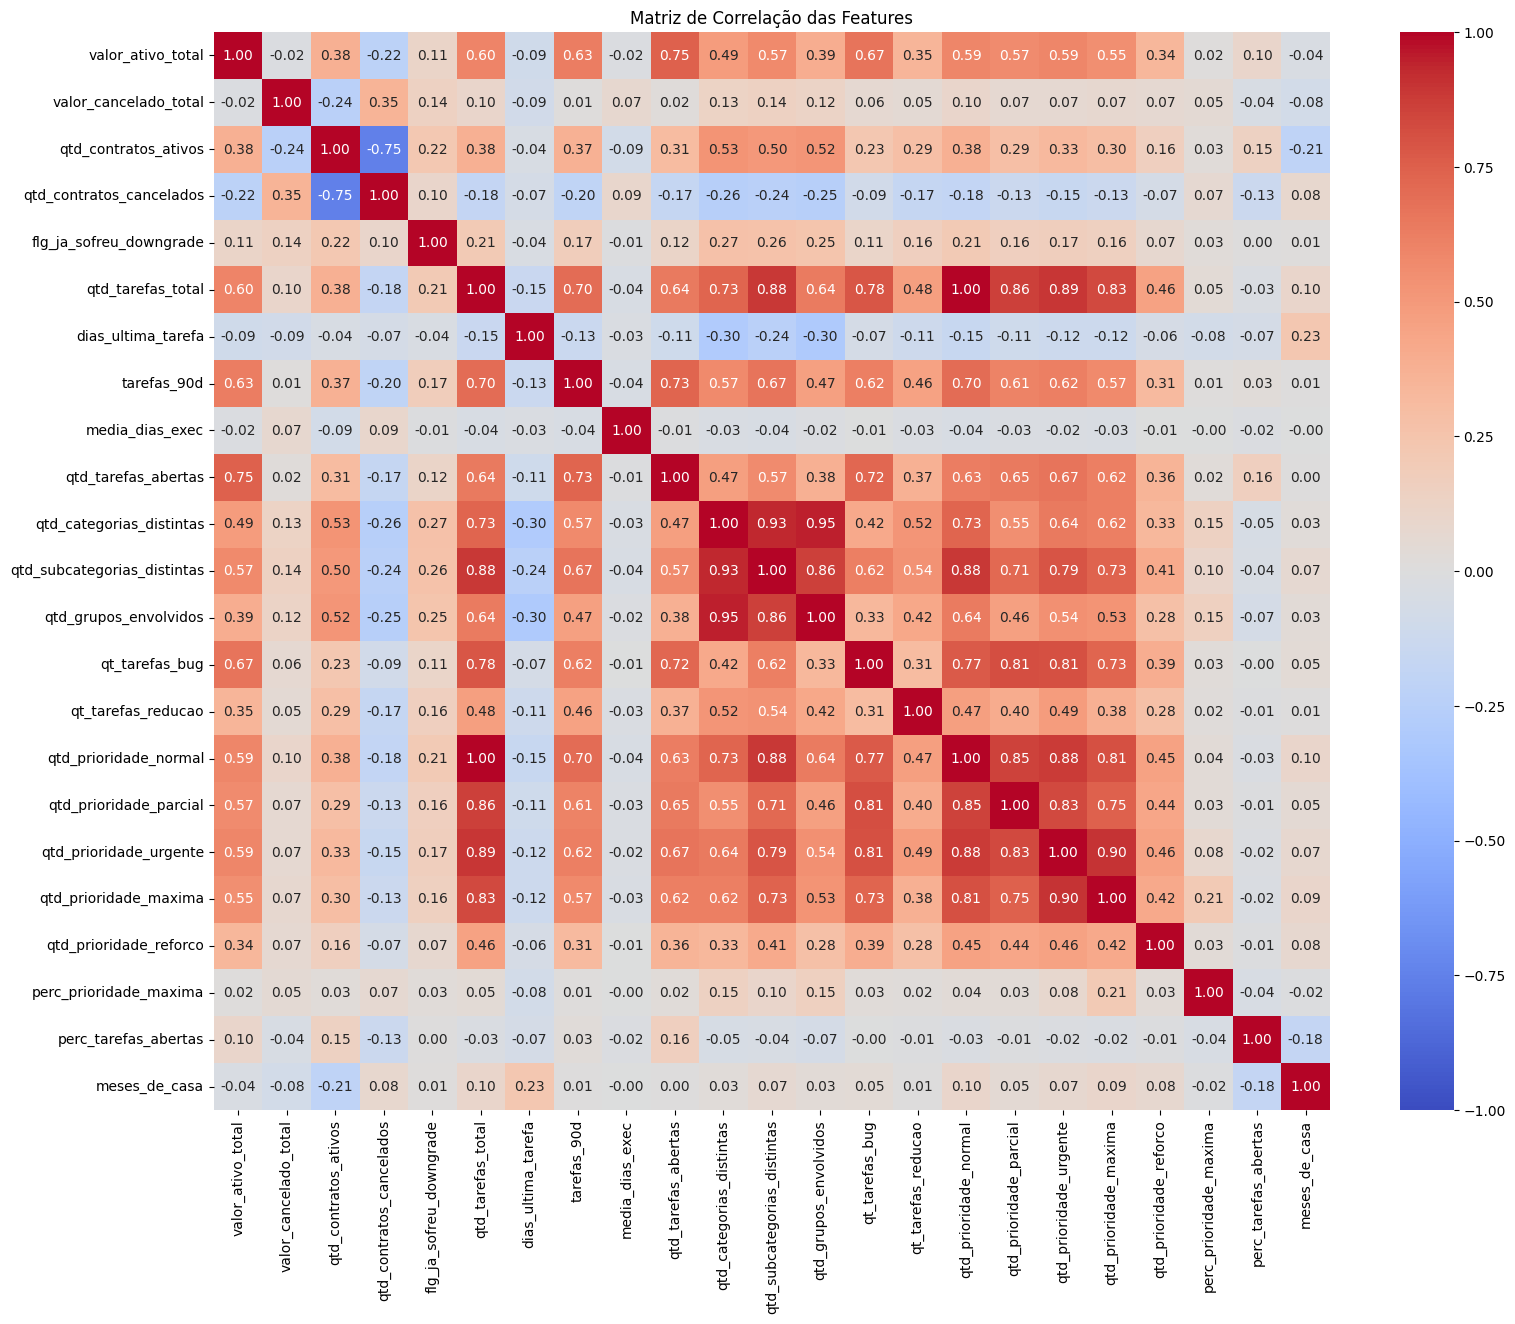

Sugestão de variáveis para exclusão por alta correlação: ['qtd_subcategorias_distintas', 'qtd_grupos_envolvidos', 'qtd_prioridade_normal', 'qtd_prioridade_parcial', 'qtd_prioridade_urgente', 'qtd_prioridade_maxima']


In [20]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

# Filtrando correlações muito altas (Acima de 0.85 ou abaixo de -0.85)
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop}")

# DICA DE ANALISTA: Se 'qtd_tarefas_total' e 'qtd_prioridade_normal' estiverem > 0.85, 
# mantenha apenas a total e descarte as abertas/prioridades absolutas, focando nos percentuais (%_prioridade_maxima).
# Caso queira dropar dinamicamente:
# X = X.drop(columns=to_drop)

In [21]:
colunas_data_leakage = ['valor_ativo_total',
                        'valor_cancelado_total',
                        'qtd_contratos_ativos',
                        'qtd_contratos_cancelados'
                        ]
to_drop_completo = to_drop + colunas_data_leakage
to_drop_completo

['qtd_subcategorias_distintas',
 'qtd_grupos_envolvidos',
 'qtd_prioridade_normal',
 'qtd_prioridade_parcial',
 'qtd_prioridade_urgente',
 'qtd_prioridade_maxima',
 'valor_ativo_total',
 'valor_cancelado_total',
 'qtd_contratos_ativos',
 'qtd_contratos_cancelados']

In [22]:
X_limpo = X.drop(columns=to_drop_completo)
X_limpo

,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,media_dias_exec,qtd_tarefas_abertas,qtd_categorias_distintas,qt_tarefas_bug,qt_tarefas_reducao,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,meses_de_casa
0,0,1,0,0,208.0000,0,1,0,0,0,0.00,0.00,156
1,0,561,15,14,23.1960,8,39,41,1,0,1.25,1.43,301
2,0,64,265,0,12.2500,0,14,0,0,0,3.13,0.00,181
3,0,14,126,0,30.1429,0,8,0,0,0,7.14,0.00,66
4,0,62,392,0,67.2581,0,17,0,0,0,0.00,0.00,171
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4663,0,1,6,1,0.0000,1,1,0,0,0,0.00,100.00,0
4664,0,1,5,1,0.0000,1,1,0,0,0,0.00,100.00,9
4665,0,1,2,1,0.0000,1,1,0,0,0,0.00,100.00,0
4666,0,0,43,0,0.0000,0,0,0,0,0,0.00,0.00,1


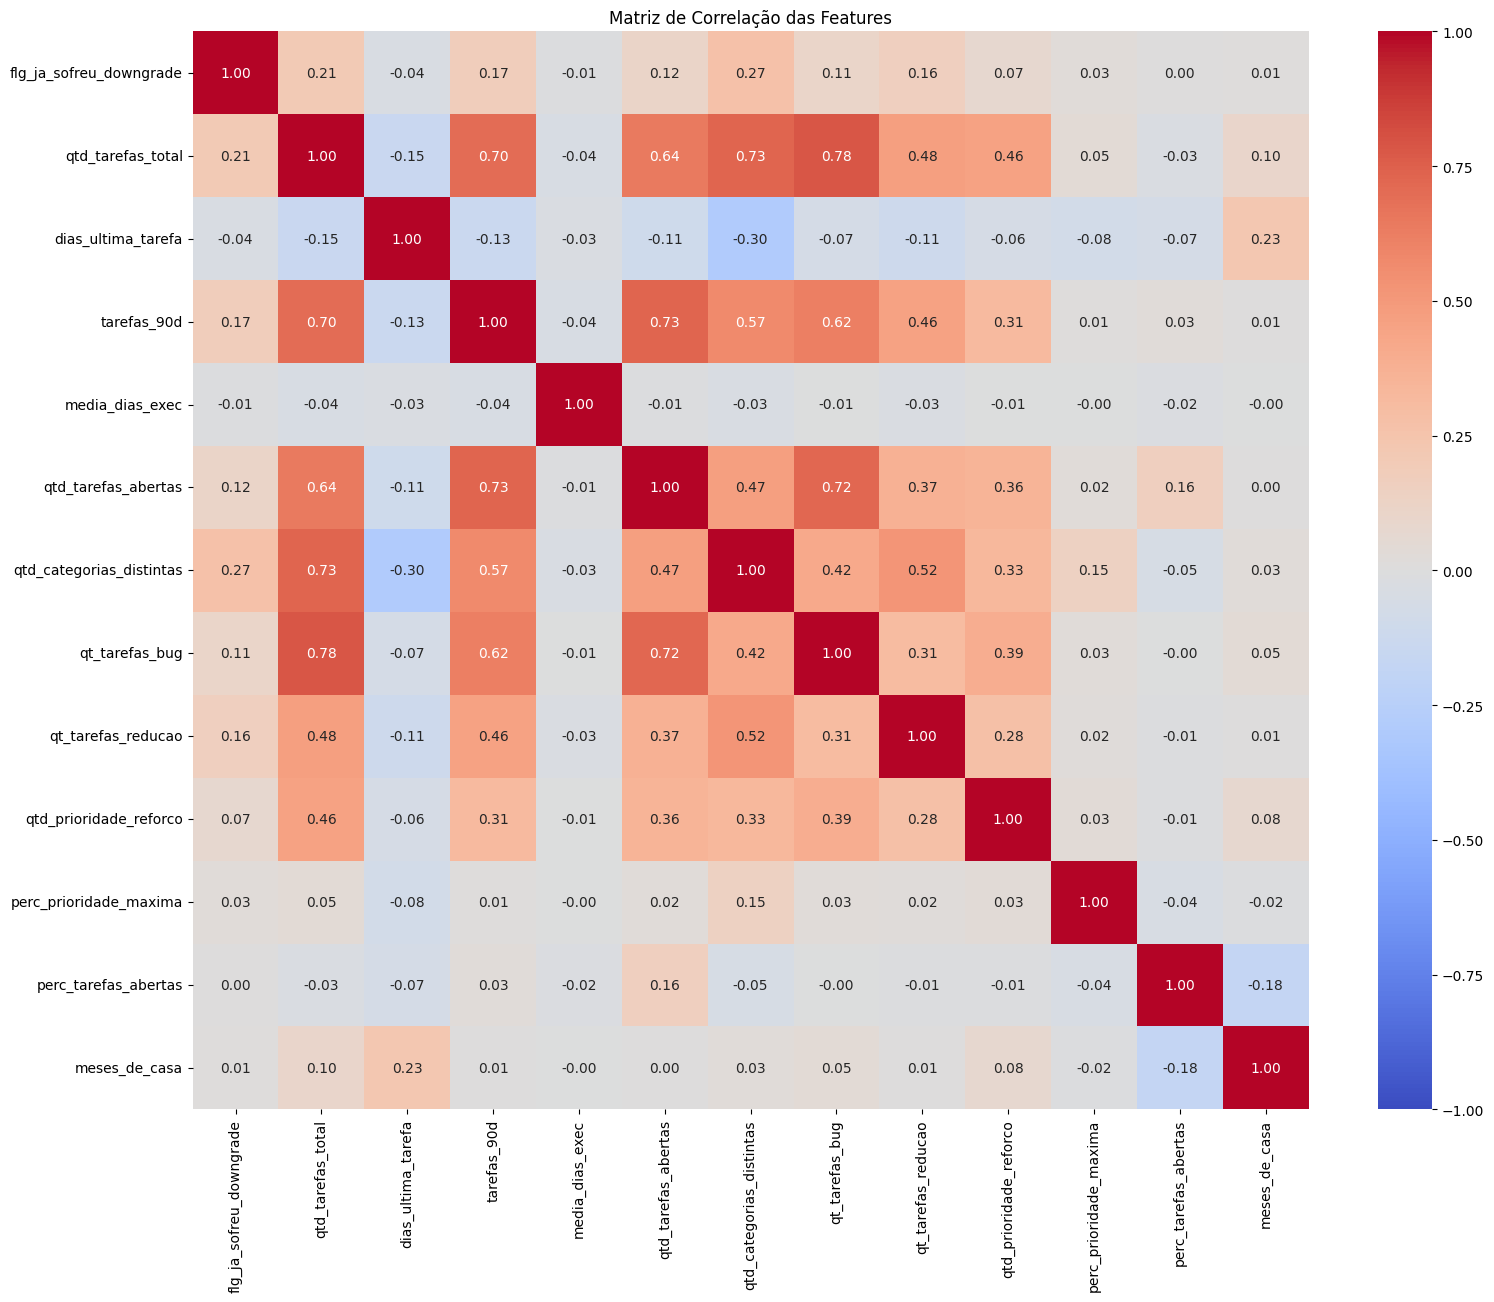

Sugestão de variáveis para exclusão por alta correlação: []


In [23]:
# Calculando a matriz de correlação de Pearson
plt.figure(figsize=(18, 14))
matrix_corr = X_limpo.corr()

# Plotando o Heatmap
sns.heatmap(matrix_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matriz de Correlação das Features")
plt.show()

# Filtrando correlações muito altas (Acima de 0.85 ou abaixo de -0.85)
upper_tri = matrix_corr.where(np.triu(np.ones(matrix_corr.shape), k=1).astype(bool))
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.85)]
print(f"Sugestão de variáveis para exclusão por alta correlação: {to_drop}")

# DICA DE ANALISTA: Se 'qtd_tarefas_total' e 'qtd_prioridade_normal' estiverem > 0.85, 
# mantenha apenas a total e descarte as abertas/prioridades absolutas, focando nos percentuais (%_prioridade_maxima).
# Caso queira dropar dinamicamente:
# X = X.drop(columns=to_drop)

# Análise de Outliers

In [ ]:
# DataFrame com as colunas que restaram após o drop de correlação
df_features = X_limpo.copy()

print("--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---")
print(f"{'Métrica / Feature':<30} | {'Qtd Outliers':<12} | {'Porcentagem':<12}")
print("-" * 62)

colunas_com_outliers_criticos = []

for col in df_features.columns:
    # Ignora colunas que já são flags binárias (0 ou 1), pois nelas não existem outliers estatísticos
    if df_features[col].nunique() <= 2:
        continue

    Q1 = df_features[col].quantile(0.25)
    Q3 = df_features[col].quantile(0.75)
    IQR = Q3 - Q1

    # Definição estatística de Outlier: além de 1.5 vezes o IQR
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers = df_features[(df_features[col] < limite_inferior) | (df_features[col] > limite_superior)]
    total_outliers = len(outliers)
    porcentagem = (total_outliers / len(df_features)) * 100

    print(f"{col:<30} | {total_outliers:<12} | {porcentagem:.2f}%")

    # Se mais de 5% dos dados forem outliers, ou se houver um volume absoluto considerável
    if porcentagem > 5.0:
        colunas_com_outliers_criticos.append(col)

--- ANÁLISE QUANTITATIVA DE OUTLIERS (MÉTODO IQR) ---
Métrica / Feature              | Qtd Outliers | Porcentagem 
--------------------------------------------------------------
qtd_tarefas_total              | 575          | 12.32%
dias_ultima_tarefa             | 388          | 8.31%
tarefas_90d                    | 1126         | 24.12%
media_dias_exec                | 317          | 6.79%
qtd_tarefas_abertas            | 627          | 13.43%
qtd_categorias_distintas       | 158          | 3.38%
qt_tarefas_bug                 | 744          | 15.94%
qt_tarefas_reducao             | 397          | 8.50%
qtd_prioridade_reforco         | 170          | 3.64%
perc_prioridade_maxima         | 512          | 10.97%
perc_tarefas_abertas           | 627          | 13.43%
meses_de_casa                  | 19           | 0.41%


In [25]:
# Dedivo à presença de outliers críticos, vamos aplicar o RobustScaler,
# que é mais resistente a valores extremos, para padronizar as features numéricas.

# Divisão de Treino/Teste e Padronização (Scaling)

In [26]:
# Separando os dados em Treino (75%) e Teste (25%) garantindo a mesma proporção de Churn (stratify)
X_train, X_test, y_train, y_test = train_test_split(
    X_limpo, y, test_size=0.25, random_state=42, stratify=y
)

# Padronizando as variáveis (Z-score: Média=0, Desvio Padrão=1)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Base de Treino: {X_train_scaled.shape[0]} amostras")
print(f"Base de Teste:  {X_test_scaled.shape[0]} amostras")

Base de Treino: 3501 amostras
Base de Teste:  1167 amostras


# Treinamento do Modelo e Avaliação de Métricas

In [27]:
# Treinando a Regressão Logística
modelo_churn = LogisticRegression(max_iter=1000, random_state=42)
modelo_churn.fit(X_train_scaled, y_train)

# Predições
y_pred  = modelo_churn.predict(X_test_scaled)
y_probs = modelo_churn.predict_proba(X_test_scaled)[:, 1] # Probabilidade de ser 1 (Churn)

In [47]:
# Criamos uma cópia do X_test original (sem escala) para manter as colunas legíveis
df_validacao = X_test.copy()

# Resgatamos o 'cod_cliente' do dataset original usando o mesmo índice do teste
df_validacao['cod_cliente'] = dataset.loc[X_test.index, 'cod_cliente']

# Adicionamos as colunas do Target Real, da Predição e da Probabilidade
df_validacao['churn_real'] = y_test
df_validacao['churn_predito'] = y_pred
df_validacao['probabilidade_churn'] = y_probs

# Criamos uma coluna de diagnóstico para filtrar erros e acertos facilmente
df_validacao['diagnostico'] = np.where(
    (df_validacao['churn_real'] == 1) & (df_validacao['churn_predito'] == 1), 'Verdadeiro Positivo (Acertou Churn)',
    np.where(
        (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 0), 'Verdadeiro Negativo (Acertou Ativo)',
        np.where(
            (df_validacao['churn_real'] == 0) & (df_validacao['churn_predito'] == 1), 'Falso Positivo (Alarme Falso)', 
            'Falso Negativo (Churn Invisível)'
        )
    )
)

# Reorganiza as colunas para deixar os IDs e Resultados no começo do DataFrame
colunas_ordenadas = ['cod_cliente', 'churn_real', 'churn_predito', 'probabilidade_churn', 'diagnostico']
df_validacao = df_validacao[colunas_ordenadas].reset_index(drop=True)
df_validacao.to_csv('dados_brutos\\validacao_modelo_churn.csv', index=False)
df_validacao.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico
0,43825,1,1,0.810380,Verdadeiro Positivo (Acertou Churn)
1,45626,1,1,0.607961,Verdadeiro Positivo (Acertou Churn)
2,38152,1,1,0.891371,Verdadeiro Positivo (Acertou Churn)
3,38283,1,1,0.925668,Verdadeiro Positivo (Acertou Churn)
4,17134,1,1,0.972508,Verdadeiro Positivo (Acertou Churn)


# Métricas

<Figure size 600x600 with 0 Axes>

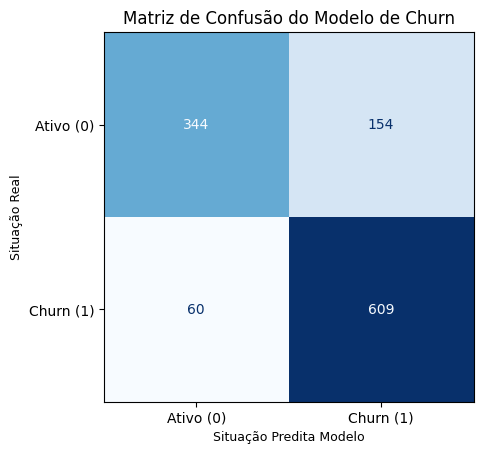

In [29]:
# Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ativo (0)', 'Churn (1)'])
plt.figure(figsize=(6, 6))
disp.plot(cmap='Blues', values_format='d', colorbar=False) # 'd' força a exibição como número inteiro

plt.title('Matriz de Confusão do Modelo de Churn')
plt.ylabel('Situação Real', fontsize=9)
plt.xlabel('Situação Predita Modelo', fontsize=9)
plt.show()

In [32]:
# Relatório de Classificação (Precision, Recall, F1-Score)
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))

--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.85      0.69      0.76       498
           1       0.80      0.91      0.85       669

    accuracy                           0.82      1167
   macro avg       0.82      0.80      0.81      1167
weighted avg       0.82      0.82      0.81      1167



ROC AUC Score: 0.90


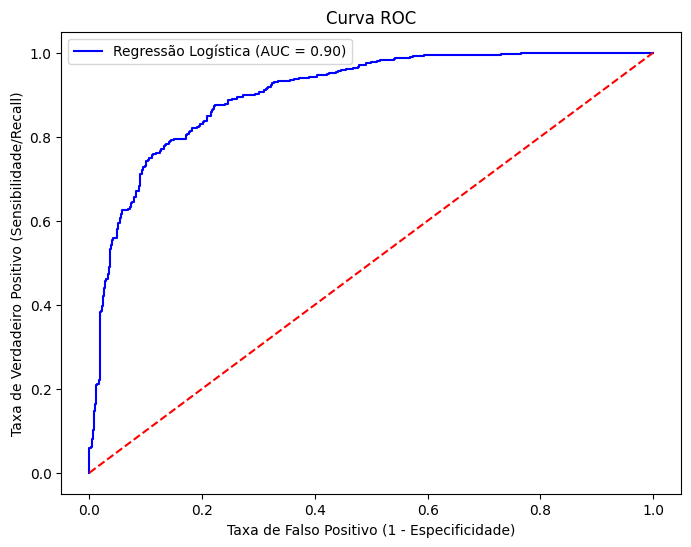

In [33]:
# ROC AUC Score
auc = roc_auc_score(y_test, y_probs)
print(f"ROC AUC Score: {auc:.2f}")

# Plotando a Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'Regressão Logística (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Sensibilidade/Recall)')
plt.title('Curva ROC')
plt.legend()
plt.show()

# Odds_Ratio

In [34]:
# Coeficientes de probabilidade
# Acima de 1.0: Aumenta a chance de Churn
# Abaixo de 1.0: Reduz a chance de Churn

# Extraindo coeficientes
coeficientes_churn = pd.DataFrame({
    'Feature': X_limpo.columns,
    'Coeficiente': modelo_churn.coef_[0]
})

# Calculando a Razão de Chance (Odds Ratio)
coeficientes_churn['Odds_Ratio'] = coeficientes_churn['Coeficiente'].apply(lambda x: math.exp(x))

# Calcula o impacto percentual dependendo se o valor está acima ou abaixo de 1.0
coeficientes_churn['Impacto_Percentual'] = np.where(
    coeficientes_churn['Odds_Ratio'] >= 1.0,
    (coeficientes_churn['Odds_Ratio'] - 1) * 100,
    (1 - coeficientes_churn['Odds_Ratio']) * 100
)

# Cria uma coluna de texto formatada para facilitar a leitura no relatório
coeficientes_churn['Impacto_Formatado'] = np.where(
    coeficientes_churn['Odds_Ratio'] >= 1.0,
    "+" + coeficientes_churn['Impacto_Percentual'].round(2).astype(str) + "% (Aumento de Risco)",
    "-" + coeficientes_churn['Impacto_Percentual'].round(2).astype(str) + "% (Redução de Risco)"
)

coeficientes_churn = coeficientes_churn.sort_values(by='Coeficiente', ascending=False).reset_index(drop=True)
coeficientes_churn.to_csv('dados_resultado\\coeficientes_churn.csv', index=False)
coeficientes_churn

,Feature,Coeficiente,Odds_Ratio,Impacto_Percentual,Impacto_Formatado
0,meses_de_casa,1.236438,3.443325,244.332544,+244.33% (Aumento de Risco)
1,media_dias_exec,0.269124,1.308817,30.881743,+30.88% (Aumento de Risco)
2,qtd_tarefas_total,0.100395,1.105607,10.560731,+10.56% (Aumento de Risco)
3,qt_tarefas_bug,0.091618,1.095946,9.594583,+9.59% (Aumento de Risco)
4,perc_prioridade_maxima,0.038670,1.039427,3.942737,+3.94% (Aumento de Risco)
5,qtd_prioridade_reforco,0.037425,1.038134,3.813374,+3.81% (Aumento de Risco)
6,perc_tarefas_abertas,-0.024837,0.975468,2.453152,-2.45% (Redução de Risco)
7,qt_tarefas_reducao,-0.212488,0.808570,19.143029,-19.14% (Redução de Risco)
8,qtd_tarefas_abertas,-0.480440,0.618511,38.148885,-38.15% (Redução de Risco)
9,dias_ultima_tarefa,-0.480883,0.618237,38.176251,-38.18% (Redução de Risco)


# Alarmes Falsos (Falsos Positivos)

In [35]:
df_fp = df_validacao[df_validacao['diagnostico'] == 'Falso Positivo (Alarme Falso)'].sort_values(by='probabilidade_churn', ascending=False)
df_fp.to_csv('dados_resultado\\falsos_positivos_churn.csv', index=False)
df_fp.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,media_dias_exec,qtd_tarefas_abertas,qtd_categorias_distintas,qt_tarefas_bug,qt_tarefas_reducao,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,meses_de_casa
189,12178,0,1,0.972308,Falso Positivo (Alarme Falso),0,24,317,0,41.4167,0,7,0,0,0,0.0,0.0,251
1010,43385,0,1,0.972111,Falso Positivo (Alarme Falso),0,1,758,0,259.0000,0,1,0,0,0,0.0,0.0,23
272,17692,0,1,0.968005,Falso Positivo (Alarme Falso),0,12,495,0,63.8333,0,4,0,0,0,0.0,0.0,201
184,11992,0,1,0.963900,Falso Positivo (Alarme Falso),0,22,100,0,103.1818,0,9,0,0,0,0.0,0.0,181
219,45814,0,1,0.954221,Falso Positivo (Alarme Falso),0,3,600,0,221.0000,0,2,0,0,0,0.0,0.0,19


# Churns Invisíveis (Falsos Negativos)

In [36]:
df_fn = df_validacao[df_validacao['diagnostico'] == 'Falso Negativo (Churn Invisível)'].sort_values(by='probabilidade_churn', ascending=True)
df_fn.to_csv('dados_resultado\\falsos_negativos_churn.csv', index=False)
df_fn.head()

,cod_cliente,churn_real,churn_predito,probabilidade_churn,diagnostico,flg_ja_sofreu_downgrade,qtd_tarefas_total,dias_ultima_tarefa,tarefas_90d,media_dias_exec,qtd_tarefas_abertas,qtd_categorias_distintas,qt_tarefas_bug,qt_tarefas_reducao,qtd_prioridade_reforco,perc_prioridade_maxima,perc_tarefas_abertas,meses_de_casa
348,21584,1,0,0.000009,Falso Negativo (Churn Invisível),0,369,0,10,18.6033,0,31,7,1,0,2.17,0.00,165
1070,44926,1,0,0.000175,Falso Negativo (Churn Invisível),0,309,42,5,13.7124,1,26,5,4,0,2.27,0.32,42
910,40907,1,0,0.000940,Falso Negativo (Churn Invisível),0,27,5,6,9.0370,0,13,1,0,0,3.70,0.00,37
338,24591,1,0,0.004253,Falso Negativo (Churn Invisível),0,125,0,4,12.5520,0,16,1,2,0,1.60,0.00,45
833,9116,1,0,0.044103,Falso Negativo (Churn Invisível),0,253,0,0,19.2609,0,35,0,0,0,3.95,0.00,109


# Análises de Negócio

In [37]:
# dias_ultima_tarefa (Coef: 1.69 | Odds: 5.42)
# Análise: É o maior preditor isolado de Churn da sua empresa.
# Se o cliente para de abrir tarefas, ele está morrendo operacionalmente.
# A cada salto de desvio padrão na recência sem interagir com o
# suporte/operação, a chance dele cancelar multiplica por 5,42.

# Validação nos Erros: Olhando o arquivo de falsos_positivos_churn.csv,
# o cliente 35954 (que o modelo achava que era churn com 98% de certeza, mas continua ativo)
# está há 1.688 dias sem abrir uma única tarefa. Operacionalmente esse cliente está abandonado,
# o modelo está certíssimo em alertar risco crítico.

In [38]:
# meses_de_casa (Coef: 0.83 | Odds: 2.31)
# Análise Paradoxal: Em muitos mercados SaaS, quanto mais tempo de casa, menor o churn.
# Aqui acontece o oposto: clientes mais antigos têm mais chance de cancelar (Odds: 2.31).

# O Diagnóstico de Negócio: Isso aponta para obsolescência de produto ou fadiga de relacionamento.
# Clientes antigos (como vimos no cliente 17029 de 2011) acumulam processos pesados e, se o produto
# não evoluir com eles, eles viram alvo fácil de concorrentes mais modernos.

In [39]:
# qt_tarefas_reducao (Odds: 1.10) e qt_tarefas_bug (Odds: 1.06)
# Análise: Ambas empurram o cliente para a porta de saída.
# O atrito técnico (bug) e o sintoma claro de encolhimento de escopo comercial
# (reducao) aumentam o risco.
# Cada bug aberto deixa o cliente estatisticamente 6% mais propenso ao Churn total no futuro.

In [40]:
# flg_ja_sofreu_downgrade (Coef: -3.50 | Odds: 0.03)
# Análise: Clientes que já cancelaram contratos no passado, mas mantiveram outros ativos,
# possuem uma chance de Churn Real 97% menor (1 - 0.03) do que os outros.

# O Diagnóstico de Negócio: O downgrade funciona como uma válvula de escape financeira.
# O cliente ajusta o bolso à realidade dele, mas escolhe continuar na sua empresa.
# Ele já passou pelo momento de crise e decidiu ficar. É um grupo resiliente.

In [41]:
# qtd_categorias_distintas (Coef: -1.94 | Odds: 0.14)
# Análise: O maior fator de retenção do seu produto.
# Clientes que usam muitas categorias diferentes têm o risco de Churn reduzido em 86% (1 - 0.14).

# O Diagnóstico de Negócio: Isso se chama Aderência (Stickiness).
# Se o cliente usa o sistema apenas para uma coisa (ex: só abre tarefa de suporte),
# ele te troca fácil. Se ele usa múltiplas categorias
# o seu software está integrado na cultura dele. Desplugá-lo da empresa dói demais.

In [42]:
# tarefas_90d (Coef: -0.56 | Odds: 0.56)
# Análise: Atividade recente protege.
# Clientes com alto volume nos últimos 90 dias têm seu risco
# reduzido quase pela metade (Odds: 0.56). É o oposto complementar da recência.

In [43]:
# perc_prioridade_maxima (Odds: 1.001)
# Análise: O impacto é praticamente nulo na decisão final.
# Por que isso acontece se tarefas urgentes parecem críticas?

# O Diagnóstico de Negócio: Olhando o arquivo de falsos_negativos_churn.csv
# (onde o modelo errou e o cliente cancelou mesmo parecendo saudável), o cliente 21584
# tinha uma volumetria imensa de tarefas (369), usava 31 categorias distintas e tinha um
# percentual baixo de prioridade máxima. O modelo foi enganado pelo excesso de uso.
# Clientes podem estar usando muito o sistema apenas porque ele é complexo ou confuso.

In [44]:
# O Plano de Ação Estratégico (O que entregar para a Diretoria)
# Com esse modelo, você acabou de criar as regras de ouro para o time de Sucesso do Cliente (CS):

# Gatilho de Saúde (Health Score): O time de CS precisa focar em Diversidade de Uso
# (qtd_categorias_distintas). Se um cliente usa menos de X categorias, ele precisa de
# treinamento urgente para adotar novos módulos.

# Régua de Inatividade (dias_ultima_tarefa): Criar um alerta automatizado quando o
# cliente passar de X dias sem registrar movimentações, pois o risco se multiplica exponencialmente.

# Atenção aos Veteranos (meses_de_casa): Realizar auditorias e check-ups de satisfação
# focados em clientes com mais de 3 ou 4 anos de casa, pois eles tendem a dar churn
# por falta de atenção ou saturação.

In [45]:
# Validando a tese nos seus dados reais
# Se abrirmos o arquivo falsos_negativos_churn.csv que você gerou,
# conseguimos ver essa teoria acontecendo na prática. Veja o caso do cliente 40907:

# Ele deu Churn Real (churn_real = 1).

# O modelo calculou uma probabilidade minúscula de churn para ele (0.006), errando o diagnóstico.

# Por que o modelo errou? Olhe as métricas dele: nos últimos 90 dias, ele abriu apenas 6 tarefas.
# A recência dele era de 12 dias (relativamente baixa). Ele tinha apenas 1 bug aberto.

# Operacionalmente, a conta parecia "saudável" e sem problemas.
# Mas o que estava acontecendo de verdade?
# O cliente já tinha abandonado a ferramenta meses antes de formalizar o cancelamento, deixando uma
# volumetria baixíssima nos últimos 90 dias. Ele não reclamava porque já não se importava mais.

# O Insight de Ouro para o CS
# Um volume muito baixo de tarefas_90d é um sinal claro de falta de adoção.
# Cliente que não usa, não vê valor. E cliente que não vê valor, cancela sem fazer barulho.